# Human Immune Health Atlas: sample representation benchmark

Blood immune single-cell data from the Dynamics of Immune Health and Age study (Nature 2025, [PMID 41162704](https://pubmed.ncbi.nlm.nih.gov/41162704/)). Donors vary in age and CMV status; cells are annotated with Allen Institute AIFI labels at several resolutions. 

Ideas here are based on ideas from the R package SETA https://github.com/CellDiscoveryNetwork/SETA.

Download `human_immune_health_atlas_full.h5ad` from the Immune Health Atlas catalog:
https://apps.allenimmunology.org/aifi/resources/imm-health-atlas/downloads/scrna/

Direct link to the full object (on the order of 40 GB) - clicking starts download!:
https://allenimmunology.org/public/publication/download/84792154-cdfb-42d0-8e42-39e210e980b4/filesets/568ad40c-516a-4646-9426-bdcd7029c1f5/human_immune_health_atlas_full.h5ad

Notebook is also based on https://carmonalab.github.io/scECODA_demo/Case_Study_1.html

## Compositions

Because this dataset is very large, we benchmark methods that are highly efficient. Compositions are perfect for rapid exploratory sample level analysis. We implemented CLR in `CellGroupComposition(apply_clr=True)` to build per-sample cell type proportions and apply a centered log-ratio (CLR). The other methods in the benchmark use the same label column but aggregate cells in different ways.


## Install patpy


In [1]:
# !pip install git+https://github.com/lueckenlab/patpy.git@main
# !pip install -q pilotpy


## Import packages


In [2]:
import warnings

import matplotlib.cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
from scipy import stats
from sklearn.decomposition import PCA

import patpy

warnings.filterwarnings("ignore", category=UserWarning)


## Read the data

Set `ADATA_PATH` to your local `human_immune_health_atlas_full.h5ad`. The object should have `obsm['X_pca']` (used by pseudobulk-style methods).


In [3]:
ADATA_PATH = "/Users/kylekimler/Projects/patient-maps-playground/data/human_immune_health_atlas_full.h5ad"


In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 1821725 × 1236
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'seurat.

## Benchmark

For each AIFI resolution (L1–L3) and each method, including **PILOT** (Earth Mover's distances via `pilotpy`)—build sample distances and score them with KNN. Biological **relevant** targets and **technical** batch proxies use the same normalization as `knn_prediction_score` (technical scores inverted; Spearman scores taken in absolute value). Results are summarized in the **plottable `Table()`** (see `representation_methods_example.ipynb`).

This loop reuses the same `adata`; if you hit odd state, restart from a fresh `read_h5ad`. **PILOT** can be slow on the full atlas; reduce cells or samples if needed.


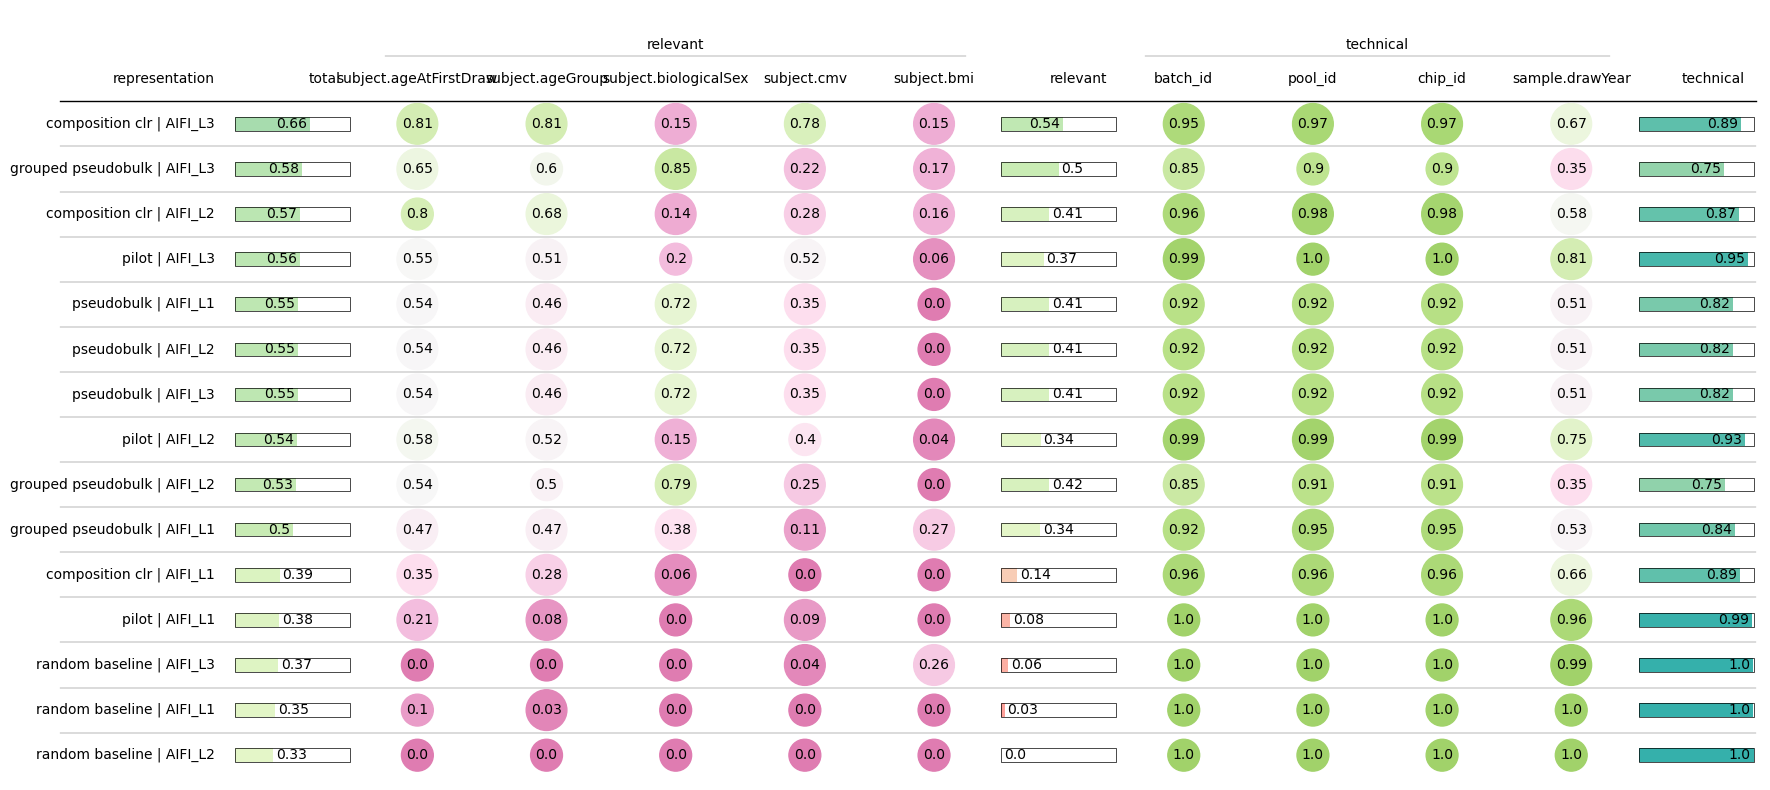

In [5]:
SAMPLE_KEY = "sample.sampleKitGuid"
LABEL_RESOLUTIONS = ["AIFI_L1", "AIFI_L2", "AIFI_L3"]
# PILOT expects a per-cell status column
PILOT_SAMPLE_STATE_COL = "subject.cmv"
# Columns used only for UMAP coloring below
AGE_COL = "subject.ageAtFirstDraw"
CMV_COL = "subject.cmv"
RNG = 67
N_NEIGHBORS = 7


# KNN tasks per covariate; "relevant" = biological, "technical" = batch / processing
BENCHMARK_SCHEMA = {
    "relevant": {
        "subject.ageAtFirstDraw": "regression",
        "subject.ageGroup": "classification",
        "subject.biologicalSex": "classification",
        "subject.cmv": "classification",
        "subject.bmi": "regression",
    },
    "technical": {
        "batch_id": "classification",
        "pool_id": "classification",
        "chip_id": "classification",
        "sample.drawYear": "regression",
    },
}

REQ_OBS = (
    {SAMPLE_KEY, CMV_COL, AGE_COL, *LABEL_RESOLUTIONS}
    | {c for bucket in BENCHMARK_SCHEMA.values() for c in bucket}
)

for col in REQ_OBS:
    assert col in adata.obs, col
assert "X_pca" in adata.obsm, "need X_pca in obsm for pseudobulk methods"


def build_method(method: str, label_key: str):
    if method == "composition_clr":
        return patpy.tl.CellGroupComposition(SAMPLE_KEY, label_key, apply_clr=True, seed=RNG)
    if method == "pseudobulk":
        return patpy.tl.Pseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "grouped_pseudobulk":
        return patpy.tl.GroupedPseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "random_baseline":
        return patpy.tl.RandomVector(SAMPLE_KEY, label_key, latent_dim=32, seed=RNG)
    if method == "pilot":
        return patpy.tl.PILOT(
            SAMPLE_KEY,
            label_key,
            sample_state_col=PILOT_SAMPLE_STATE_COL,
            layer="X_pca",
            seed=RNG,
        )
    raise ValueError(method)


METHOD_ORDER = ["composition_clr", "pseudobulk", "grouped_pseudobulk", "pilot", "random_baseline"]

rows: list[dict] = []
for label_key in LABEL_RESOLUTIONS:
    for method in METHOD_ORDER:
        m = build_method(method, label_key)
        m.prepare_anndata(adata)
        force = method.startswith("composition") or method == "pilot"
        m.calculate_distance_matrix(force=force)
        for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
            for cov_col, task in cov_map.items():
                out = m.evaluate_representation(
                    cov_col, method="knn", n_neighbors=N_NEIGHBORS, task=task
                )
                rows.append(
                    {
                        "label_key": label_key,
                        "method": method,
                        "covariate": cov_col,
                        "covariate_type": covariate_type,
                        "task": task,
                        "score": out["score"],
                        "metric": out["metric"],
                    }
                )

benchmark_long = pd.DataFrame(rows)


def _plot_score(row: pd.Series) -> float:
    s = float(row["score"])
    if row["covariate_type"] == "technical":
        s = 1.0 - s
    if row["metric"] == "spearman_r":
        s = abs(s)
    return s


benchmark_long["plot_score"] = benchmark_long.apply(_plot_score, axis=1)

bio = benchmark_long[benchmark_long["covariate_type"] == "relevant"]
tech = benchmark_long[benchmark_long["covariate_type"] == "technical"]
summary = (
    bio.groupby(["label_key", "method"], as_index=False)["plot_score"]
    .mean()
    .rename(columns={"plot_score": "bio_mean"})
    .merge(
        tech.groupby(["label_key", "method"], as_index=False)["plot_score"]
        .mean()
        .rename(columns={"plot_score": "tech_mean"}),
        on=["label_key", "method"],
        how="outer",
    )
)
summary["mean_score"] = (summary["bio_mean"] + summary["tech_mean"]) / 2.0
results = summary.sort_values("mean_score", ascending=False).reset_index(drop=True)

knn_results_wide = benchmark_long.pivot_table(
    index=["method", "label_key"],
    columns="covariate",
    values="plot_score",
    aggfunc="first",
)

plot_df = knn_results_wide.reset_index()
plot_df["representation"] = plot_df["method"].str.replace("_", " ") + " | " + plot_df["label_key"]
plot_df = plot_df.drop(columns=["method", "label_key"]).set_index("representation")

for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
    tcols = list(cov_map.keys())
    plot_df[covariate_type] = plot_df[tcols].mean(axis=1)

clin_weight = 2 / 3
plot_df["total"] = clin_weight * plot_df["relevant"] + (1 - clin_weight) * plot_df["technical"]

cols_order = ["total"]
for covariate_type in BENCHMARK_SCHEMA:
    cols_order.extend(list(BENCHMARK_SCHEMA[covariate_type].keys()))
    cols_order.append(covariate_type)

cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#FF9693", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

col_defs: list = []
col_defs.append(
    ColumnDefinition(
        "total",
        width=0.7,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap,
            "plot_bg_bar": True,
            "annotate": True,
            "height": 0.5,
            "lw": 0.5,
            "formatter": lambda x: round(x, 2),
        },
    )
)

for covariate_type in BENCHMARK_SCHEMA:
    type_cols = list(BENCHMARK_SCHEMA[covariate_type].keys())
    for col in type_cols:
        col_defs.append(
            ColumnDefinition(
                name=col,
                width=0.75,
                formatter=lambda x: round(x, 2),
                textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
                cmap=normed_cmap(benchmark_long["plot_score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
                group=covariate_type,
            )
        )
    col_defs.append(
        ColumnDefinition(
            covariate_type,
            width=0.7,
            plot_fn=bar,
            plot_kw={
                "cmap": cmap,
                "plot_bg_bar": True,
                "annotate": True,
                "height": 0.5,
                "lw": 0.5,
                "formatter": lambda x: round(x, 2),
            },
        )
    )

fig, ax = plt.subplots(figsize=(22, 10))
Table(
    plot_df[cols_order].sort_values("total", ascending=False),
    column_definitions=tuple(col_defs),
    ax=ax,
)
plt.show()


## The highest scoring method, CLR is highest on the highest-resolution labels (L3)

### In compositional analysis of ecological and microbiome data, CLR is compared with a global coherence metric, PERMANOVA. 

PERMANOVA can be useful over KNN in two situations: 
1. PERMANOVA provides a p-value metric through its permutational statistical test. 
2. PERMANOVA provides a *global* coherence metric (often plotted with 95% confidence ellipses around groups on embeddings), while the KNN better tracks local coherence in neighborhoods.

To compare these two metrics, we plot PERMANOVA with ellipses next to neighborhoods with the KNN metric.

**Left:** PCA of per-sample CLR compositions at **AIFI_L3**; **95%** bivariate normal confidence **ellipses** per **CMV** level (ordination ellipse style). An annotation box summarizes **PERMANOVA** (pseudo-F and permutation **p-value**) on the **same** Euclidean distance matrix used for CLR in patpy.

**Right:** Line segments connect each sample to its **k** nearest neighbors **in the full sample distance matrix**. An annotation box gives the **KNN** benchmark result for CMV (**k** matches `N_NEIGHBORS` above).


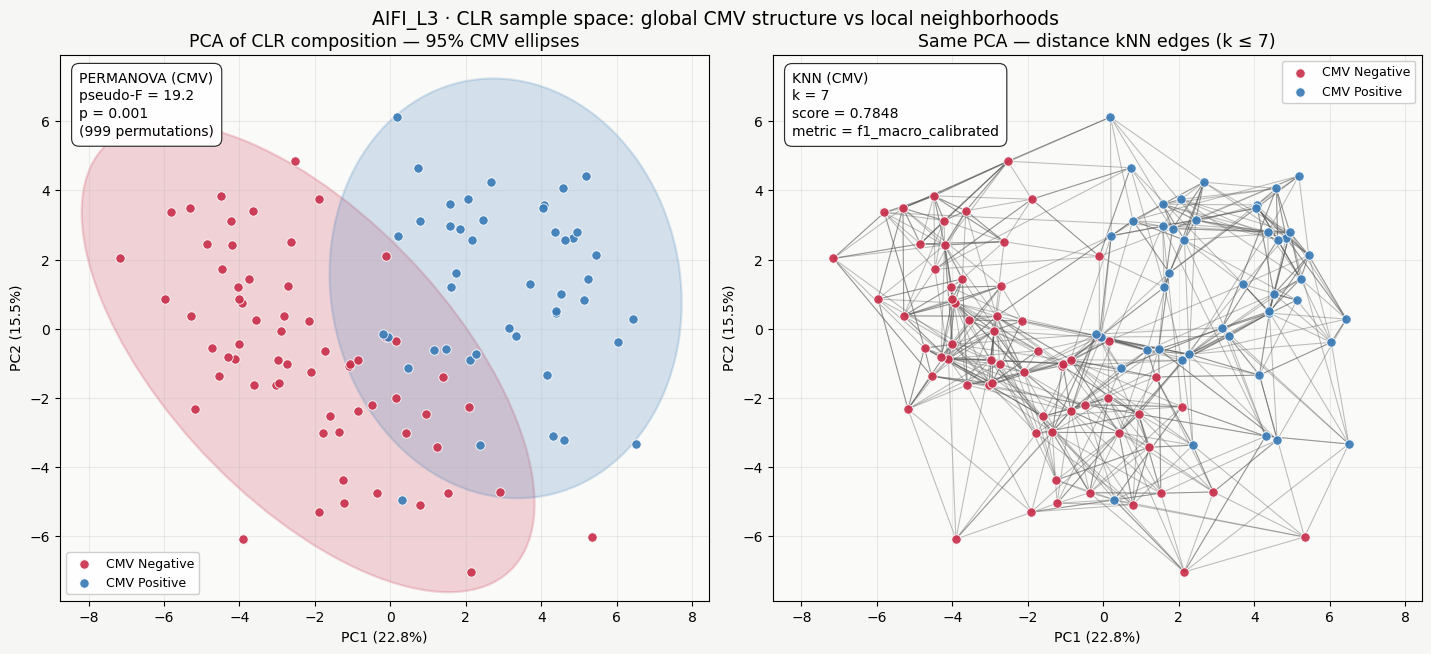

In [7]:
ELLIPSE_CHI2 = stats.chi2.ppf(0.95, 2)
ORD_LABEL = "AIFI_L3"
N_EDGE = int(min(N_NEIGHBORS, 12))
PERMANOVA_PERMUTATIONS = 999

m_ord = patpy.tl.CellGroupComposition(SAMPLE_KEY, ORD_LABEL, apply_clr=True, seed=RNG)
m_ord.prepare_anndata(adata)
D_ord = np.asarray(m_ord.calculate_distance_matrix(force=True), dtype=float).copy()
X_ord = np.asarray(m_ord.sample_representation, dtype=float)
samples_ord = list(m_ord.sample_representation.index)
sample_table = adata.obs.drop_duplicates(subset=[SAMPLE_KEY], keep="first").set_index(SAMPLE_KEY)
cmv_ord = sample_table.loc[samples_ord, CMV_COL].astype(str)

pca_ord = PCA(n_components=2, random_state=RNG)
XY_ord = pca_ord.fit_transform(X_ord)

perm_ord = m_ord.evaluate_representation(
    CMV_COL, method="permanova", permutations=PERMANOVA_PERMUTATIONS
)
knn_ord = m_ord.evaluate_representation(
    CMV_COL, method="knn", n_neighbors=N_NEIGHBORS, task="classification"
)


def _ellipse_mu_wh_theta(xy: np.ndarray):
    if xy.shape[0] < 3:
        return None
    cov = np.cov(xy.T)
    det = np.linalg.det(cov)
    if det < 1e-14:
        return None
    mu = xy.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = np.maximum(vals[order], 1e-12)
    vecs = vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w = 2 * np.sqrt(ELLIPSE_CHI2 * vals[0])
    h = 2 * np.sqrt(ELLIPSE_CHI2 * vals[1])
    return mu, w, h, theta


D_nn = D_ord.copy()
np.fill_diagonal(D_nn, np.inf)
n_s = D_nn.shape[0]
edge_pairs = []
if n_s > 1:
    k_take = min(N_EDGE, n_s - 1)
    for i in range(n_s):
        part = np.argpartition(D_nn[i], k_take - 1)[:k_take]
        nn = part[part != i]
        if len(nn) == 0:
            continue
        nn = nn[np.argsort(D_nn[i, nn])]
        for j in nn[:N_EDGE]:
            edge_pairs.append((i, int(j)))

segments = [[XY_ord[i], XY_ord[j]] for i, j in edge_pairs]
levels = sorted(cmv_ord.unique())
_q = np.linspace(0.08, 0.92, max(len(levels), 1))
color_cmv = {lev: plt.cm.Spectral(_q[i]) for i, lev in enumerate(levels)}

fig, (ax_e, ax_g) = plt.subplots(
    1,
    2,
    figsize=(14.2, 6.2),
    layout="constrained",
    facecolor="#f6f6f4",
)
for ax in (ax_e, ax_g):
    ax.set_facecolor("#fafaf8")

for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    pts = XY_ord[sel]
    col = color_cmv[lev]
    ell = _ellipse_mu_wh_theta(pts)
    if ell is not None:
        mu, w_r, h_r, th = ell
        ax_e.add_patch(
            Ellipse(
                xy=mu,
                width=w_r,
                height=h_r,
                angle=th,
                facecolor=col,
                edgecolor=col,
                lw=1.6,
                alpha=0.2,
                zorder=1,
            )
        )
    ax_e.scatter(
        pts[:, 0],
        pts[:, 1],
        s=46,
        color=col,
        alpha=0.92,
        edgecolors="white",
        linewidths=0.65,
        label=f"CMV {lev}",
        zorder=3,
    )

perm_lines = (
    "PERMANOVA (CMV)"
    + chr(10)
    + f"pseudo-F = {perm_ord['score']:.4g}"
    + chr(10)
    + f"p = {perm_ord['p_value']:.4g}"
    + chr(10)
    + f"({PERMANOVA_PERMUTATIONS} permutations)"
)
ax_e.text(
    0.03,
    0.97,
    perm_lines,
    transform=ax_e.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, linewidth=0.85),
)
ax_e.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_e.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_e.set_title("PCA of CLR composition — 95% CMV ellipses", fontsize=12.5)
ax_e.legend(framealpha=0.94, loc="best", fontsize=9)
ax_e.grid(True, alpha=0.22)

if segments:
    ax_g.add_collection(
        LineCollection(segments, colors="#5c5c5c", alpha=0.4, linewidths=0.75, zorder=0)
    )
for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    pts = XY_ord[sel]
    col = color_cmv[lev]
    ax_g.scatter(
        pts[:, 0],
        pts[:, 1],
        s=46,
        color=col,
        alpha=0.92,
        edgecolors="white",
        linewidths=0.65,
        label=f"CMV {lev}",
        zorder=3,
    )

knn_lines = (
    "KNN (CMV)"
    + chr(10)
    + f"k = {N_NEIGHBORS}"
    + chr(10)
    + f"score = {knn_ord['score']:.4f}"
    + chr(10)
    + f"metric = {knn_ord['metric']}"
)
ax_g.text(
    0.03,
    0.97,
    knn_lines,
    transform=ax_g.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, linewidth=0.85),
)
ax_g.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_g.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_g.set_title(f"Same PCA — distance kNN edges (k ≤ {N_EDGE})", fontsize=12.5)
ax_g.legend(framealpha=0.94, loc="best", fontsize=9)
ax_g.grid(True, alpha=0.22)
ax_g.set_xlim(ax_e.get_xlim())
ax_g.set_ylim(ax_e.get_ylim())

fig.suptitle("AIFI_L3 · CLR sample space: global CMV structure vs local neighborhoods", fontsize=13.5, y=1.03)
plt.show()


## Biological readout: which AIFI cell types drive the sample PCA?

The benchmark table ranks representation × label resolution combinations. Here we take the **top-scoring CLR composition run** (usually a high-resolution AIFI label) and treat **samples** as observations and **cell types** as variables—**analogous to a gene-by-sample PCA**, but for compositional contrasts often linked to **immune aging** (age / CMV) in this cohort.

1. **PC loadings** (`scanpy.pl.pca_loadings`): for PC1 and PC2 we show the **five strongest positive and negative** contributions (cell types whose CLR coordinates push samples along each axis).
2. **PC scatter**: the same PCA coloured by **CMV** and **age group** so you can see whether separation along an axis aligns with those labels (the exact geometry is cohort-specific).
3. **CMV within age group**: for each **age group** with enough donors and both CMV levels, we plot **mean CLR difference** (second vs first CMV level in sorted label order) for the **cell types that vary most across strata**—a simple “what shifts with CMV **within** a roughly homogeneous age bin?” view.

*Interpretation caveat:* PC axes are **orthogonal directions of maximal variance**, not guaranteed to equal “age” or “CMV” as factors; loadings name the cell types that **statistically** contribute most to those directions. Sample sizes per age×CMV bin are printed for transparency.


In [ ]:
_clr_best = results[results["method"] == "composition_clr"].sort_values("mean_score", ascending=False)
WIN_LABEL = str(_clr_best.iloc[0]["label_key"])
print(
    f"CLR benchmark leader: {WIN_LABEL} (mean_score={_clr_best.iloc[0]['mean_score']:.4f}; "
    f"bio_mean={_clr_best.iloc[0]['bio_mean']:.4f}, tech_mean={_clr_best.iloc[0]['tech_mean']:.4f})"
)

m_bio = patpy.tl.CellGroupComposition(SAMPLE_KEY, WIN_LABEL, apply_clr=True, seed=RNG)
m_bio.prepare_anndata(adata)
m_bio.calculate_distance_matrix(force=True)

X_bio = np.asarray(m_bio.sample_representation.values, dtype=np.float32)
cell_types = m_bio.sample_representation.columns.astype(str)
samples_bio = list(m_bio.sample_representation.index)
_obs_use = [CMV_COL, "subject.ageGroup", AGE_COL]
sample_meta = adata.obs.drop_duplicates(subset=[SAMPLE_KEY], keep="first").set_index(SAMPLE_KEY)
obs_bio = sample_meta.loc[samples_bio, _obs_use].copy()

sdata = sc.AnnData(X=X_bio, obs=obs_bio, var=pd.DataFrame(index=cell_types))
sdata.layers["clr"] = sdata.X.copy()
sc.pp.scale(sdata, zero_center=True)  # Scanpy PCA convention; loadings refer to scaled CLR
sc.tl.pca(sdata, n_comps=10, zero_center=False)

_n_load = int(min(5, sdata.n_vars))
sc.pl.pca_loadings(sdata, components=[1, 2], n_points=_n_load, include_lowest=True)
plt.show()

sc.pl.embedding(
    sdata,
    basis="pca",
    color=[CMV_COL, "subject.ageGroup"],
    ncols=2,
    size=45,
    alpha=0.85,
    frameon=True,
    title=[f"CMV ({WIN_LABEL} CLR PCA)", f"Age group ({WIN_LABEL} CLR PCA)"],
)
plt.show()

# --- CMV-associated composition within each age group (mean CLR difference) ---
ageg_col = "subject.ageGroup"
cmv_levels = sorted(sdata.obs[CMV_COL].dropna().unique(), key=str)
if len(cmv_levels) > 2:
    print(f"Note: CMV has {len(cmv_levels)} levels; using alphabetically first two for contrast.")
if len(cmv_levels) < 2:
    print("CMV: need at least two levels for within-age comparison.")
else:
    v_low, v_high = cmv_levels[0], cmv_levels[1]
    print(f"CMV contrast (alphabetical order): mean(CLR | {v_high}) − mean(CLR | {v_low})")

_x = pd.crosstab(sdata.obs[ageg_col], sdata.obs[CMV_COL], margins=False)
print("Samples per age group × CMV:\n", _x)

diff_by_age = []
used_ages = []
min_n_cmv = 5
for ag in sorted(sdata.obs[ageg_col].dropna().unique(), key=str):
    m_age = sdata.obs[ageg_col].astype(str) == str(ag)
    if int(m_age.sum()) < 15:
        continue
    sd = sdata[m_age].copy()
    if sd.obs[CMV_COL].nunique() < 2:
        continue
    i_lo = sd.obs[CMV_COL].astype(str) == str(v_low)
    i_hi = sd.obs[CMV_COL].astype(str) == str(v_high)
    if int(i_lo.sum()) < min_n_cmv or int(i_hi.sum()) < min_n_cmv:
        continue
    delta = np.asarray(sd[i_hi].layers["clr"].mean(0) - sd[i_lo].layers["clr"].mean(0)).ravel()
    diff_by_age.append(delta)
    used_ages.append(str(ag))

if len(diff_by_age) >= 1:
    Dmat = np.column_stack(diff_by_age)
    delta_df = pd.DataFrame(Dmat, index=cell_types, columns=used_ages)
    top_ct = delta_df.abs().max(axis=1).nlargest(18).index
    fig, ax = plt.subplots(figsize=(max(5.0, 1.2 * len(used_ages)), 8.2))
    im = ax.imshow(delta_df.loc[top_ct].values, aspect="auto", cmap="RdBu_r", vmin=-np.quantile(np.abs(delta_df.loc[top_ct].values), 0.98), vmax=np.quantile(np.abs(delta_df.loc[top_ct].values), 0.98))
    ax.set_xticks(range(len(used_ages)))
    ax.set_xticklabels(used_ages, rotation=25, ha="right")
    ax.set_yticks(range(len(top_ct)))
    ax.set_yticklabels(top_ct, fontsize=9)
    ax.set_xlabel("Age group")
    ax.set_ylabel(f"AIFI label ({WIN_LABEL})")
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.set_label(f"Δ mean CLR ({v_high} − {v_low})")
    fig.suptitle(
        f"CMV-associated CLR shifts within age group\n({v_high} minus {v_low}; pre-scaling CLR layer)",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()
else:
    print("Skipping stratified heatmap: not enough donors per age×CMV bin (see counts above).")


## UMAP on distances for top runs

UMAPs can capture nonlinear relationships. For a fair comparison between PILOT and CLR, we plot and compare each method with important covariates with UMAPs below


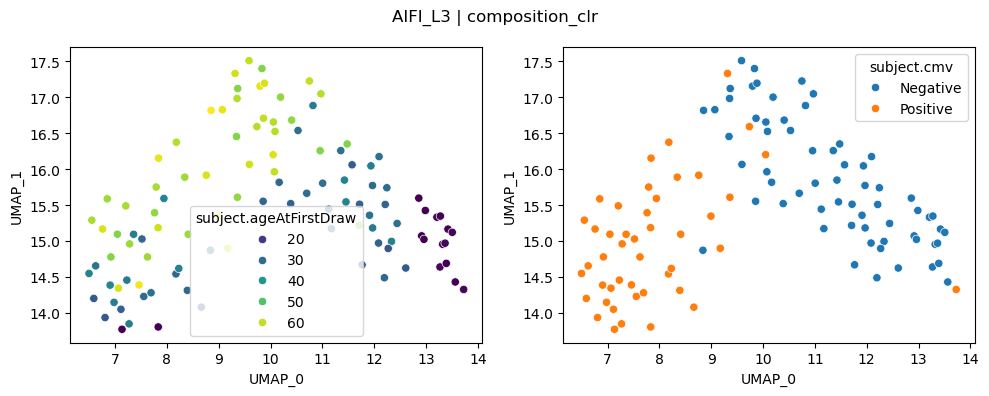

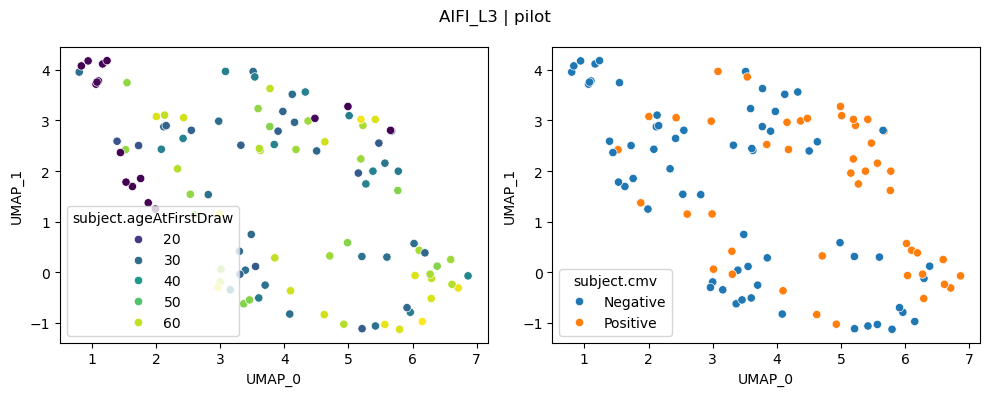

In [8]:
top2 = results.sort_values("mean_score", ascending=False).head(2)
for _, row in top2.iterrows():
    label_key = row["label_key"]
    method = row["method"]
    m = build_method(method, label_key)
    m.prepare_anndata(adata)
    m.calculate_distance_matrix(force=method.startswith("composition"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    m.plot_embedding(method="UMAP", metadata_cols=[AGE_COL, CMV_COL], axes=axes)
    fig.suptitle(f"{label_key} | {method}")
    plt.tight_layout()
